(14)=
# Chapter 14: Monte Carlo Simulation

---
> **🎤 INSTRUCTOR SCRIPT — Chapter 14: Monte Carlo Simulation**
>
> **Learning objectives for today:**
> 1. Understand what Monte Carlo simulation is and when to use it
> 2. Implement the three-step MC recipe in NumPy
> 3. Apply MC to estimate a process failure rate
>
> **Pacing (~75 min total):**
> - Section 14.1 intro + motivation: ~10 min
> - Section 14.2 π estimation demo: ~20 min
> - Section 14.3 engineering example (4 steps): ~35 min
> - Wrap-up / Q&A: ~10 min
>
> **Before class:** Make sure outputs are cleared so students see cells run live.
---

(14.1)=
## 14.1 What Is Monte Carlo Simulation?

Imagine you're designing a reactor, but you don't know the exact feed temperature — it fluctuates a bit every day. How does that uncertainty in temperature affect the conversion you get out?

You could try to work this out analytically (with calculus and error propagation formulas), but what if the relationship between temperature and conversion is nonlinear? What if multiple inputs are uncertain at once?

**Monte Carlo simulation** is a simple, powerful alternative:

> Instead of solving the math analytically, just *try it thousands of times* with randomly sampled inputs, and look at what comes out.

The name comes from the Monte Carlo casino in Monaco — the core idea is random sampling, just like rolling dice.

### The three-step recipe

1. **Define your uncertain inputs** as probability distributions  
   (e.g., "temperature is normally distributed with mean 400 K and std 5 K")

2. **Draw thousands of random samples** from those distributions  
   (e.g., sample 100,000 temperatures from that normal distribution)

3. **Run your model for every sample**, then **look at the output distribution**  
   (e.g., compute conversion for each temperature → plot the histogram of conversions)


### Why is this useful for chemical engineers?

- **Uncertainty propagation**: How does uncertainty in activation energy $E_a$ affect predicted conversion?
- **Process reliability**: What fraction of batches will meet the purity spec given normal operating variability?
- **Risk assessment**: What is the probability that reactor temperature exceeds a safety limit?
- **Equipment sizing**: Given uncertain feed compositions, what reactor volume ensures 99% of scenarios achieve the desired conversion?

---
> **🎤 [14.1 — Intro, ~10 min]**
>
> *Open with this scenario — hold up (or draw) a bucket divided into two sections:*
>
> "Imagine you have a bucket split into two sections by a divider — but the divider is irregular, so you can't easily calculate the exact area of each section. How would you figure out the area ratio?"
>
> - Let students suggest ideas. They'll say: measure with a ruler, use geometry, etc.
> - Then: "What if the shape is really complicated — curved divider, weird corners? Measuring gets tedious."
> - "Here's a different idea: **throw balls into the bucket randomly, thousands of times.** If your throws are truly random and uniform, the fraction of balls that land in each section will converge to the true area ratio."
>
> **Write on the board:**
> ```
> Area of Section A     balls in Section A
> ─────────────────  ≈  ──────────────────   (as N → ∞)
>  Total bucket area       total balls thrown
> ```
>
> "You didn't measure anything. You didn't do any geometry. You just counted. That's the core idea of Monte Carlo — **use random sampling to estimate something you'd otherwise have to calculate analytically.**"
>
> - "The more balls you throw, the better your estimate."
> - "And this scales: if the bucket had 10 sections with complicated shapes, the method is exactly the same — just count."
>
> **Bridge to the chapter:**
> "In chemical engineering, the 'bucket' is your model, and the 'sections' are regions like 'batch passes spec' vs 'batch fails spec'. Instead of solving the math, we sample thousands of random operating conditions and count outcomes."
>
> **Walk through the three-step recipe verbally before showing any code:**
> 1. "Define your uncertain inputs as distributions"
> 2. "Sample randomly — thousands of times"
> 3. "Run your model for each sample, look at what comes out"
---

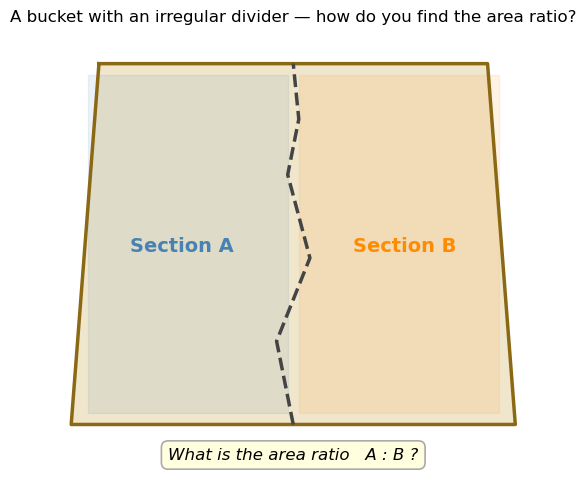

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(7, 5))
ax.set_xlim(0, 10)
ax.set_ylim(0, 8)
ax.axis('off')
ax.set_aspect('equal')

# ── Bucket outline (slightly tapered) ────────────────────────────────────────
bucket_x = [1.5, 1.0, 9.0, 8.5, 1.5]
bucket_y = [7.5, 1.0, 1.0, 7.5, 7.5]
ax.fill(bucket_x, bucket_y, color='#f0e6cc', zorder=1)
ax.plot(bucket_x, bucket_y, color='#8B6914', linewidth=2.5, zorder=2)

# ── Irregular divider (dashed squiggly line) ──────────────────────────────────
divider_x = [5.0, 4.7, 5.3, 4.9, 5.1, 5.0]
divider_y = [1.0, 2.5, 4.0, 5.5, 6.5, 7.5]
ax.plot(divider_x, divider_y, color='#444', linewidth=2.5, linestyle='--', zorder=3)

# ── Section shading ───────────────────────────────────────────────────────────
ax.fill([1.3, 4.9, 4.9, 1.3], [1.2, 1.2, 7.3, 7.3],
        color='steelblue', alpha=0.10, zorder=1)
ax.fill([5.1, 8.7, 8.7, 5.1], [1.2, 1.2, 7.3, 7.3],
        color='darkorange', alpha=0.10, zorder=1)

# ── Section labels ────────────────────────────────────────────────────────────
ax.text(3.0, 4.2, 'Section A', ha='center', va='center',
        fontsize=14, fontweight='bold', color='steelblue', zorder=4)
ax.text(7.0, 4.2, 'Section B', ha='center', va='center',
        fontsize=14, fontweight='bold', color='darkorange', zorder=4)

# ── Question annotation ───────────────────────────────────────────────────────
ax.text(5.0, 0.45,
        'What is the area ratio   A : B ?',
        ha='center', va='center', fontsize=12, style='italic',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow',
                  edgecolor='#aaa', linewidth=1.2), zorder=6)

ax.set_title('A bucket with an irregular divider — how do you find the area ratio?',
             fontsize=12, pad=10)
plt.tight_layout()
plt.savefig('bucket_area_ratio.png', dpi=300)
plt.show()

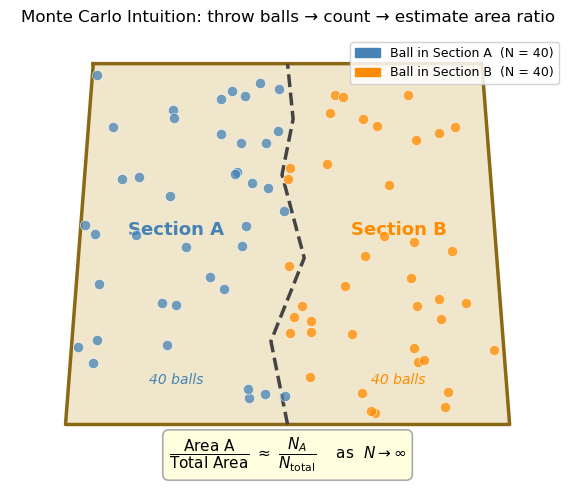

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(7, 5))
ax.set_xlim(0, 10)
ax.set_ylim(0, 8)
ax.axis('off')
ax.set_aspect('equal')

# ── Bucket outline (slightly tapered) ────────────────────────────────────────
bucket_x = [1.5, 1.0, 9.0, 8.5, 1.5]
bucket_y = [7.5, 1.0, 1.0, 7.5, 7.5]
ax.fill(bucket_x, bucket_y, color='#f0e6cc', zorder=1)
ax.plot(bucket_x, bucket_y, color='#8B6914', linewidth=2.5, zorder=2)

# ── Irregular divider (dashed squiggly line) ──────────────────────────────────
divider_x = [5.0, 4.7, 5.3, 4.9, 5.1, 5.0]
divider_y = [1.0, 2.5, 4.0, 5.5, 6.5, 7.5]
ax.plot(divider_x, divider_y, color='#444', linewidth=2.5, linestyle='--', zorder=3)

# ── Section labels ────────────────────────────────────────────────────────────
ax.text(3.0, 4.5, 'Section A', ha='center', va='center',
        fontsize=13, fontweight='bold', color='steelblue', zorder=4)
ax.text(7.0, 4.5, 'Section B', ha='center', va='center',
        fontsize=13, fontweight='bold', color='darkorange', zorder=4)

# ── Scatter random balls inside the bucket ────────────────────────────────────
rng = np.random.default_rng(seed=5)

def in_bucket(x, y):
    left  = 1.0 + 0.5 * (y - 1.0) / 6.5
    right = 9.0 - 0.5 * (y - 1.0) / 6.5
    return (left < x < right) and (1.2 < y < 7.3)

n_balls = 80
count_A = 0
balls_plotted = 0
while balls_plotted < n_balls:
    bx = rng.uniform(1.2, 8.8)
    by = rng.uniform(1.2, 7.3)
    if in_bucket(bx, by):
        in_A = bx < 5.0
        color = 'steelblue' if in_A else 'darkorange'
        if in_A:
            count_A += 1
        ax.scatter(bx, by, s=55, color=color, alpha=0.75, zorder=5,
                   edgecolors='white', linewidths=0.5)
        balls_plotted += 1

count_B = n_balls - count_A

# ── Ball count labels ─────────────────────────────────────────────────────────
ax.text(3.0, 1.8, f'{count_A} balls', ha='center', va='center',
        fontsize=10, color='steelblue', style='italic', zorder=6)
ax.text(7.0, 1.8, f'{count_B} balls', ha='center', va='center',
        fontsize=10, color='darkorange', style='italic', zorder=6)

# ── Formula box ───────────────────────────────────────────────────────────────
ax.text(5.0, 0.45,
        r'$\dfrac{\mathrm{Area\ A}}{\mathrm{Total\ Area}}\ \approx\ '
        r'\dfrac{N_A}{N_\mathrm{total}}$    as  $N \to \infty$',
        ha='center', va='center', fontsize=11,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow',
                  edgecolor='#aaa', linewidth=1.2), zorder=6)

# ── Legend ────────────────────────────────────────────────────────────────────
ax.legend(handles=[
    mpatches.Patch(color='steelblue',  label=f'Ball in Section A  (N = {count_A})'),
    mpatches.Patch(color='darkorange', label=f'Ball in Section B  (N = {count_B})'),
], loc='upper right', fontsize=9, framealpha=0.85)

ax.set_title('Monte Carlo Intuition: throw balls → count → estimate area ratio',
             fontsize=12, pad=10)
plt.tight_layout()
plt.savefig('bucket_area_ratio_monte_carlo.png', dpi=300)
plt.show()

(14.2)=
## 14.2 Building Intuition: Estimating π by Throwing Darts

Before tackling engineering problems, let's build intuition with a playful classic example.

**The setup:** Imagine throwing darts randomly at a square dartboard. Inside the square, there's a quarter-circle drawn in the corner. If your throws are truly random (uniform), what fraction of darts land inside the quarter-circle?

Run the cell below to see it — then we'll work out the math.

---
> **🎤 [14.2 — π estimation, ~20 min]**
>
> *Before running anything:* "Let's think about this geometrically first."
> - Ask: "If I throw a dart randomly at this unit square, what's the probability it lands inside the quarter-circle?"
> - Let students work it out: area of quarter-circle = π/4, area of square = 1, so P = π/4 ≈ 0.785.
> - "So if I throw enough darts and count, I can estimate π. That's Monte Carlo."
>
> **Run the diagram cell** (next one). Let it sink in visually before moving to the simulation.
---

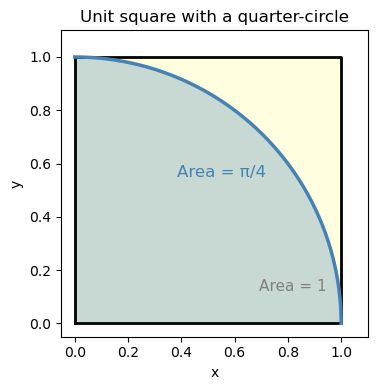

In [7]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(4, 4))

# Square
ax.fill([0, 1, 1, 0], [0, 0, 1, 1], color='lightyellow', zorder=0)
ax.plot([0, 1, 1, 0, 0], [0, 0, 1, 1, 0], 'k-', linewidth=2)

# Quarter-circle region
theta = np.linspace(0, np.pi/2, 300)
ax.fill_between(np.cos(theta), np.sin(theta), 0,
                color='steelblue', alpha=0.3, label='Quarter-circle  (area = π/4)')
ax.plot(np.cos(theta), np.sin(theta), 'steelblue', linewidth=2.5)

# Labels
ax.text(0.55, 0.55, 'Area = π/4', color='steelblue', fontsize=12, ha='center')
ax.text(0.82, 0.12, 'Area = 1', color='gray',      fontsize=11, ha='center')

ax.set_aspect('equal')
ax.set_xlim(-0.05, 1.1); ax.set_ylim(-0.05, 1.1)
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Unit square with a quarter-circle')
plt.tight_layout()
plt.show()

Notice that the blue darts (inside the quarter-circle) fill roughly **78%** of the square — and $\pi/4 \approx 0.785$. That's no coincidence!

The square has area $1 \times 1 = 1$.  
The quarter-circle of radius 1 has area $\dfrac{\pi}{4}$.

So the fraction of darts inside is:
$$
\frac{\text{darts inside}}{\text{total darts}} \approx \frac{\pi/4}{1} = \frac{\pi}{4}
\quad \Longrightarrow \quad
\hat{\pi} \approx 4 \times \frac{\text{darts inside}}{\text{total darts}}
$$

We can use this to *estimate* $\pi$ just by counting random points. Let's do it properly with more darts.

---
> **🎤 [After showing diagram — transition to code]**
>
> Point to the math on screen: "So the formula is simple: π ≈ 4 × (# inside) / (# total). Now let's actually do it."
>
> **Before running the simulation cell**, walk students through the code structure:
> - `rng = np.random.default_rng(seed=0)` — "This sets up our random number generator. The seed makes it reproducible — same result every time we run it. Important for debugging and sharing results."
> - `x = rng.random(N)` — "N uniform random numbers between 0 and 1. These are our dart x-coordinates."
> - `inside = (x**2 + y**2) <= 1.0` — "This is a boolean array. True for every dart inside the circle. NumPy checks all N darts at once — no loop needed."
> - `pi_estimate = 4.0 * np.sum(inside) / N` — "Count the Trues, multiply by 4."
>
> **Run the cell. Then ask:** "We got ~3.13. Why isn't it exactly π?" → Statistical fluctuation. More darts = closer.
>
> **Key teaching moment:** "Notice there's no for-loop. We generated all N dart throws at once as arrays. This is the NumPy way — vectorized. It's also much faster."
---

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# --- Step 1: Set up the random number generator ---
# Using a fixed seed so results are reproducible (same "random" numbers every run)
rng = np.random.default_rng(seed=0)

# --- Step 2: Throw random darts ---
N = 20_000   # number of darts (try changing this!)

x = rng.random(N)   # x-coordinates uniformly between 0 and 1
y = rng.random(N)   # y-coordinates uniformly between 0 and 1

# --- Step 3: Check which darts land inside the quarter-circle ---
# A point (x, y) is inside the quarter-circle if x² + y² ≤ 1
inside = (x**2 + y**2) <= 1.0

# --- Step 4: Estimate π ---
pi_estimate = 4.0 * np.sum(inside) / N

print(f"Number of darts: {N}")
print(f"Darts inside quarter-circle: {np.sum(inside)}")
print(f"Fraction inside: {np.mean(inside):.4f}")
print(f"Estimated π = 4 × {np.mean(inside):.4f} = {pi_estimate:.4f}")
print(f"True π      = {np.pi:.4f}")
print(f"Error       = {abs(pi_estimate - np.pi):.4f}")

Number of darts: 20000
Darts inside quarter-circle: 15709
Fraction inside: 0.7854
Estimated π = 4 × 0.7854 = 3.1418
True π      = 3.1416
Error       = 0.0002


### Visualizing the dart throw

Let's plot the darts — blue for inside the quarter-circle, red for outside. You can see how the ratio of blue to total gives us π/4.

---
> **🎤 [Scatter plot — visualizing the dart throw]**
>
> "Now let's actually *see* the darts. Run this cell."
>
> **After the plot appears, point out:**
> - "Each blue dot landed inside the quarter-circle — $x^2 + y^2 \leq 1$. Each red dot landed outside."
> - "The black curve is the boundary. Notice how the blue region fills roughly 78% of the square — that's our $\pi/4$."
> - "The title already shows our estimate. With N = 5,000 it's close but not exact."
>
> **Live demo — change N and re-run:**
> - Set `N = 100` → re-run both cells. The scatter is sparse and the estimate is rough (~2.9 to 3.3).
> - Set `N = 50000` → the scatter fills in densely and the estimate stabilizes near 3.14.
> - "More darts = better estimate. But *how much* better? That's what the next plot shows."
---

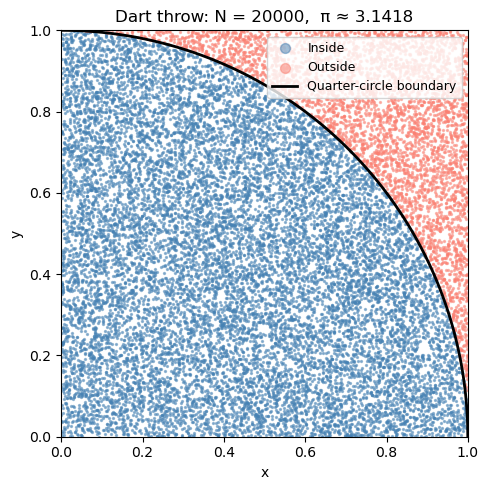

In [14]:
fig, ax = plt.subplots(figsize=(5, 5))

ax.scatter(x[inside],  y[inside],  s=2, color='steelblue', alpha=0.5, label='Inside')
ax.scatter(x[~inside], y[~inside], s=2, color='salmon',    alpha=0.5, label='Outside')

# Draw the quarter-circle boundary
theta = np.linspace(0, np.pi/2, 300)
ax.plot(np.cos(theta), np.sin(theta), 'k-', linewidth=2, label='Quarter-circle boundary')

ax.set_aspect('equal')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title(f'Dart throw: N = {N},  π ≈ {pi_estimate:.4f}')
ax.legend(fontsize=9, markerscale=5)
plt.tight_layout()
plt.show()

### How many darts do we need?

More darts = better estimate. But how fast does the estimate improve?

The key insight: the error in a Monte Carlo estimate shrinks as $\sim 1/\sqrt{N}$.  
That means to get **10× more accurate**, you need **100× more samples**.

This is Monte Carlo's main limitation — it's not very efficient for 1D problems. But it shines for high-dimensional problems (many uncertain inputs), where traditional methods become impractical.

---
> **🎤 [Convergence — 1/√N rule]**
>
> Before running: "Here's a key question — if I want my estimate to be 10× more accurate, how many more darts do I need?"
> - Let students guess. Common answers: 10×, or 100×.
> - Correct answer: **100×**, because error ∝ 1/√N. To halve the error, quadruple N.
>
> **Run the convergence plot.** Point out:
> - x-axis is log scale — you can see the estimate "settling in" as N grows
> - The red band is ±1/√N — it narrows as N increases
> - Even at 50,000 samples, there's still some residual error
>
> "This is Monte Carlo's tradeoff: it's easy to set up and works for any model, but it converges slowly. For 1D problems, numerical integration is faster. But for problems with 10 uncertain inputs? Monte Carlo is often the only practical option."
>
> *Transition:* "Okay, now let's use this for something real."
---

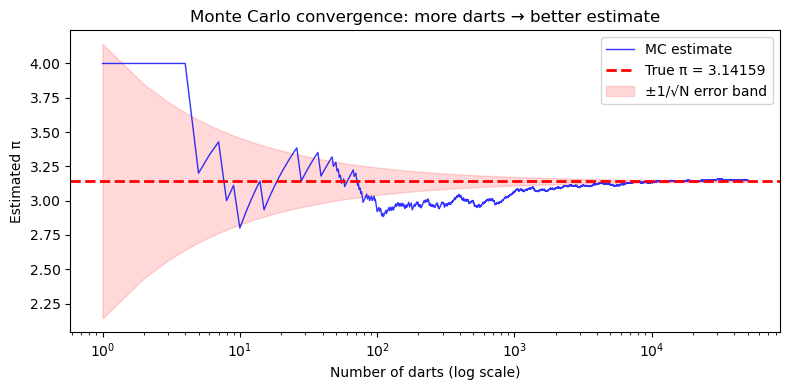

Final estimate with 50,000 darts: π ≈ 3.14968  (true: 3.14159)


In [15]:
# Throw 50,000 darts and track the running estimate of π
rng2 = np.random.default_rng(seed=0)
N_total = 50_000

x_all = rng2.random(N_total)
y_all = rng2.random(N_total)
inside_all = (x_all**2 + y_all**2) <= 1.0

# Running estimate after each dart
N_run = np.arange(1, N_total + 1)
pi_running = 4.0 * np.cumsum(inside_all) / N_run

# Plot convergence
fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(N_run, pi_running, 'b-', linewidth=1, alpha=0.8, label='MC estimate')
ax.axhline(np.pi, color='red', linestyle='--', linewidth=2, label=f'True π = {np.pi:.5f}')
ax.fill_between(N_run, np.pi - 1/np.sqrt(N_run), np.pi + 1/np.sqrt(N_run),
                alpha=0.15, color='red', label='±1/√N error band')
ax.set_xlabel('Number of darts (log scale)')
ax.set_ylabel('Estimated π')
ax.set_title('Monte Carlo convergence: more darts → better estimate')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Final estimate with {N_total:,} darts: π ≈ {pi_running[-1]:.5f}  (true: {np.pi:.5f})")

(14.3)=
## 14.3 A Real Engineering Problem: Process Reliability

Now let's apply Monte Carlo to a chemical engineering scenario.

### Problem statement

A chemical product must have **purity ≥ 97.5%** to be sold. The purity depends on two process variables that fluctuate daily due to normal operating variability:

| Variable | Symbol | Distribution |
|----------|--------|-------------|
| Residence time (s) | $\tau$ | $\mathcal{N}(\mu=120,\, \sigma=12)$ |
| Temperature (K) | $T$ | $\mathcal{N}(\mu=400,\, \sigma=8)$ |

The purity model is:
$$
\text{Purity} = 100 \times \left(1 - 0.2\, e^{-k(T)\,\tau} \right), \quad k(T) = \exp\!\left(\frac{-1550}{T}\right)
$$

**Question:** What fraction of batches will fail the purity spec?

We'll build up to the full simulation in four steps:
1. Visualize the input distributions
2. Compute purity at the mean values — and ask: is that enough information?
3. Sample a few batches by hand to see success and failure cases
4. Run the full Monte Carlo

---
> **🎤 [14.3 — Engineering problem intro, ~5 min]**
>
> Read the problem statement aloud (or have a student read it). Then ask:
> - "What are the two uncertain inputs here?" → τ and T
> - "What does the purity model look like? Is it linear in τ and T?" → No — exponential in both
> - "If I just plug in τ = 120 s and T = 400 K, will that tell me the failure rate?" → No! Nonlinearity means the tail behavior matters.
>
> "We're going to build up to the full simulation in four steps. Don't skip ahead — each step adds something."
>
> **Write on board:** `Purity = f(τ, T)` where both τ and T are random → Purity is also random → we want P(Purity < 97.5%).
---

### Step 1: Visualize the input distributions

Before running any simulation, let's see what the two uncertain inputs look like.
Each day, τ and T are drawn from their respective normal distributions.


---
> **🎤 [Step 1 — Visualize inputs]**
>
> "Before any simulation, always look at your inputs. This is good practice."
>
> Run the cell. Point out:
> - Both are bell curves (normal distributions)
> - τ has larger relative spread (σ/μ = 10%) vs T (σ/μ = 2%)
> - "The residence time is actually more variable relative to its mean. That will matter."
>
> Ask students: "Which input do you think has more impact on purity — τ or T?" Let them guess. (Answer revealed by Step 4 scatter plot.)
---

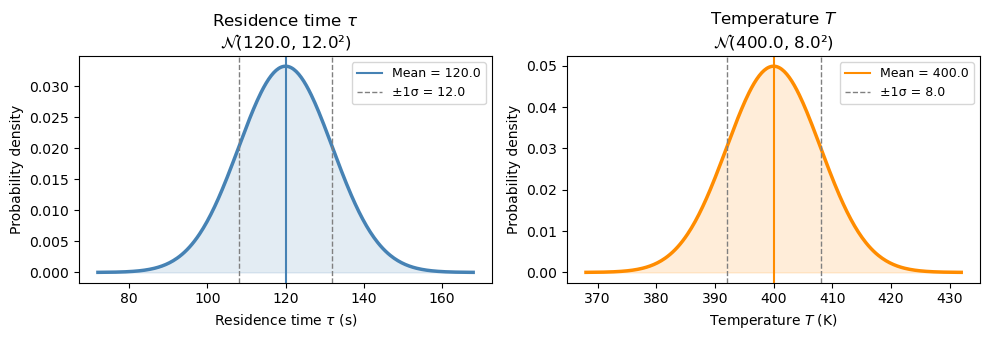

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

tau_mean, tau_std = 120.0, 12.0   # residence time (s)
T_mean,   T_std   = 400.0,  8.0   # temperature (K)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

for ax, mean, std, label, unit, color in [
    (axes[0], tau_mean, tau_std, r'Residence time $\tau$', 's',  'steelblue'),
    (axes[1], T_mean,   T_std,   r'Temperature $T$',       'K',  'darkorange'),
]:
    x = np.linspace(mean - 4*std, mean + 4*std, 300)
    ax.plot(x, stats.norm.pdf(x, mean, std), color=color, linewidth=2.5)
    ax.fill_between(x, stats.norm.pdf(x, mean, std), alpha=0.15, color=color)
    ax.axvline(mean,       color=color,  linestyle='-',  linewidth=1.5, label=f'Mean = {mean}')
    ax.axvline(mean - std, color='gray', linestyle='--', linewidth=1,   label=f'±1σ = {std}')
    ax.axvline(mean + std, color='gray', linestyle='--', linewidth=1)
    ax.set_xlabel(f'{label} ({unit})')
    ax.set_ylabel('Probability density')
    ax.set_title(f'{label}\n' + r'$\mathcal{N}$' + f'({mean}, {std}²)')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

### Step 2: Purity at the mean values

A natural first question: if everything runs at its mean value, what is the purity?

---
> **🎤 [Step 2 — Purity at the mean]**
>
> "A naive engineer might ask: 'What's the purity when everything is at its average?' Let's compute that first."
>
> Walk through `purity_model()`:
> - `k = exp(-1550/T)` — this is an Arrhenius-type rate constant (simplified)
> - "Higher T → larger k → faster reaction → higher purity"
> - "Longer τ → more time in reactor → higher purity"
>
> Run the cell. Output: **98.34% — comfortably above 97.5%.**
>
> **Ask the class:** "Does this mean the process is fine? Can we go home?" → Pause for responses.
> → "No! Because τ and T vary. Some batches will be worse than average."
>
> "This is the classic mistake: plugging in mean values and assuming you're safe. Monte Carlo exists to fix this mistake."
---

In [18]:
def purity_model(tau, T):
    k = np.exp(-1550.0 / T)
    return 100.0 * (1.0 - 0.2 * np.exp(-k * tau))

spec = 97.5   # minimum acceptable purity (%)

purity_at_mean = purity_model(tau_mean, T_mean)

print(f"At mean conditions:  τ = {tau_mean} s,  T = {T_mean} K")
print(f"  k(T_mean) = {np.exp(-1550/T_mean):.5f} s⁻¹")
print(f"  k·τ       = {np.exp(-1550/T_mean)*tau_mean:.3f}")
print(f"  Purity    = {purity_at_mean:.3f} %")
print()
if purity_at_mean >= spec:
    print(f"  Passes spec ({spec}%) at the mean — but does every batch pass?")
else:
    print(f"  Already fails spec ({spec}%) at the mean!")

At mean conditions:  τ = 120.0 s,  T = 400.0 K
  k(T_mean) = 0.02075 s⁻¹
  k·τ       = 2.491
  Purity    = 98.343 %

  Passes spec (97.5%) at the mean — but does every batch pass?


### Step 3: A few sampled batches — success and failure

The mean purity looks fine. But each real batch runs at a slightly different τ and T. Let's sample 10 batches and compute purity for each one to see how much it varies.

---
> **🎤 [Step 3 — 10 sample batches]**
>
> "Let's simulate just 10 batches manually first so we can see each one individually."
>
> Run the print table. Walk through a couple of rows:
> - Batch 2: τ = 89.3 s (much shorter than mean 120 s) → FAIL. "Short residence time → less conversion → purity drops."
> - Batch 7: τ = 95.8 s → FAIL despite T being slightly high. "Still not enough time."
> - Batch 1: τ = 144.5 s → PASS easily. "Long residence time saves it."
>
> "Two out of 10 failed. Does that mean ~20% failure rate? Maybe — but 10 is too small a sample to trust. We need thousands."
>
> Run the scatter plot. Point to the (τ, T) space:
> - "Failures (X markers) are in the lower-left — low τ and moderate T."
> - "The mean point (+ marker) is safely in PASS territory, but the cloud of batches extends into failure."
>
> **Bridge to Step 4:** "Now let's run 100,000 batches. Same code — just scale N up."
---

In [21]:
rng = np.random.default_rng(seed=3)
n_preview = 10

tau_s = rng.normal(tau_mean, tau_std, n_preview)
T_s   = rng.normal(T_mean,   T_std,   n_preview)
pur_s = purity_model(tau_s, T_s)

print(f"{'Batch':>5}  {'τ (s)':>8}  {'T (K)':>8}  {'Purity (%)':>11}  {'Result':>8}")
print("-" * 50)
for i in range(n_preview):
    result = "PASS ✓" if pur_s[i] >= spec else "FAIL ✗"
    print(f"  {i+1:>3}  {tau_s[i]:>8.1f}  {T_s[i]:>8.1f}  {pur_s[i]:>11.3f}  {result:>8}")

Batch     τ (s)     T (K)   Purity (%)    Result
--------------------------------------------------
    1     144.5     401.8       99.054    PASS ✓
    2      89.3     397.2       96.706    FAIL ✗
    3     125.0     397.7       98.420    PASS ✓
    4     113.2     394.7       97.847    PASS ✓
    5     114.6     391.6       97.755    PASS ✓
    6     117.4     396.9       98.118    PASS ✓
    7      95.8     403.9       97.457    FAIL ✗
    8     117.2     398.1       98.164    PASS ✓
    9     109.6     407.7       98.269    PASS ✓
   10     159.9     398.4       99.238    PASS ✓


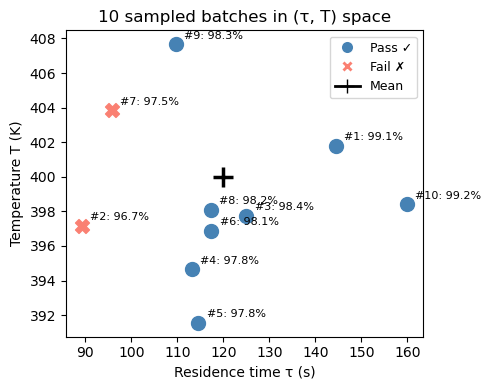

In [22]:
fig, ax = plt.subplots(figsize=(5, 4))

for i in range(n_preview):
    color  = 'steelblue' if pur_s[i] >= spec else 'salmon'
    marker = 'o'         if pur_s[i] >= spec else 'X'
    label  = ('Pass ✓' if pur_s[i] >= spec else 'Fail ✗') if i == 0 or (pur_s[i] >= spec) != (pur_s[i-1] >= spec) else ''
    ax.scatter(tau_s[i], T_s[i], color=color, marker=marker, s=100, zorder=3)
    ax.annotate(f"#{i+1}: {pur_s[i]:.1f}%", (tau_s[i], T_s[i]),
                textcoords='offset points', xytext=(6, 4), fontsize=8)

# Mark the mean
ax.scatter(tau_mean, T_mean, color='black', marker='+', s=200, linewidths=2.5,
           zorder=4, label='Mean (τ, T)')

# Legend proxies
from matplotlib.lines import Line2D
handles = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue', markersize=9, label='Pass ✓'),
    Line2D([0],[0], marker='X', color='w', markerfacecolor='salmon',    markersize=9, label='Fail ✗'),
    Line2D([0],[0], marker='+', color='black', markersize=10, linewidth=2, label='Mean'),
]
ax.legend(handles=handles, fontsize=9)
ax.set_xlabel('Residence time τ (s)')
ax.set_ylabel('Temperature T (K)')
ax.set_title('10 sampled batches in (τ, T) space')
plt.tight_layout()
plt.show()

With only 10 batches we can already see some failures — but 10 is not enough to reliably estimate the failure *rate*. We need to scale this up to thousands of batches. That's exactly what Monte Carlo does.

### Step 4: Full Monte Carlo — 100,000 batches

---
> **🎤 [Step 4 — Full Monte Carlo, ~10 min]**
>
> "Now we scale up. Same three lines of logic — just N = 100,000."
>
> Before running, ask: "What do you predict the failure rate will be?" Take 2–3 guesses from the class.
>
> Run the cell. Key results to highlight:
> - **Mean purity = ~98.3%** — same as at the mean, roughly (Jensen's inequality is small here)
> - **Std dev = ~0.6%** — the spread is what causes failures
> - **Failure rate ≈ 9%** — nearly 1 in 10 batches fails!
>
> "The process *looked* fine from the mean alone. But 9% failure is a serious quality problem."
>
> **Left plot (histogram):**
> - Red dashed line = spec limit
> - The left tail below 97.5% is the fail region
> - "The bulk of the distribution is fine, but the tail reaches into failure."
>
> **Right plot (scatter):**
> - "Red dots cluster at lower T — lower temperature slows the reaction rate."
> - Return to the earlier question: "Which matters more — τ or T?" → Both matter; failures are in the low-τ, low-T corner.
>
> **Wrap-up question for students:** "What could you change in the process to reduce the failure rate?" Possible answers:
> - Increase mean τ (longer residence time) — shifts the whole distribution right
> - Reduce σ of τ (tighter process control) — narrows the distribution
> - Increase mean T — speeds up reaction
---

  Monte Carlo results  (N = 100,000 batches)
  Mean purity:        98.265 %
  Std dev:            0.546 %
  5th percentile:     97.264 %
  Spec limit:         97.5 %
  Fraction PASSING:   0.9089  (90.89%)
  Fraction FAILING:   0.0911  (9.11%)


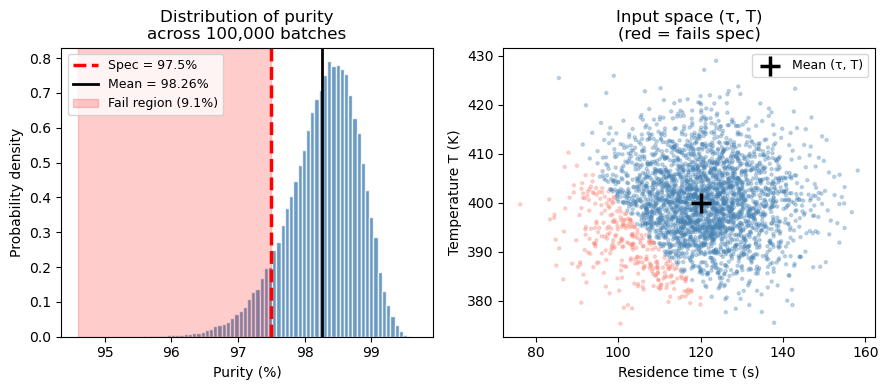

In [25]:
rng_mc = np.random.default_rng(seed=42)
N_mc   = 100_000

# Sample all batches at once
tau_mc = rng_mc.normal(tau_mean, tau_std, N_mc)
T_mc   = rng_mc.normal(T_mean,   T_std,   N_mc)
pur_mc = purity_model(tau_mc, T_mc)

frac_fail = np.mean(pur_mc < spec)
frac_pass = 1.0 - frac_fail

print("=" * 45)
print(f"  Monte Carlo results  (N = {N_mc:,} batches)")
print("=" * 45)
print(f"  Mean purity:        {np.mean(pur_mc):.3f} %")
print(f"  Std dev:            {np.std(pur_mc, ddof=1):.3f} %")
print(f"  5th percentile:     {np.percentile(pur_mc,  5):.3f} %")
print(f"  Spec limit:         {spec} %")
print(f"  Fraction PASSING:   {frac_pass:.4f}  ({100*frac_pass:.2f}%)")
print(f"  Fraction FAILING:   {frac_fail:.4f}  ({100*frac_fail:.2f}%)")
print("=" * 45)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
n_plot = 3000
colors = np.where(pur_mc[:n_plot] < spec, 'salmon', 'steelblue')

# Plot 1: purity histogram
ax = axes[0]
ax.hist(pur_mc, bins=80, density=True, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(spec, color='red', linestyle='--', linewidth=2.5, label=f'Spec = {spec}%')
ax.axvline(np.mean(pur_mc), color='k', linestyle='-', linewidth=2,
           label=f'Mean = {np.mean(pur_mc):.2f}%')
ymax = ax.get_ylim()[1]
ax.fill_betweenx([0, ymax], pur_mc.min(), spec,
                 alpha=0.2, color='red', label=f'Fail region ({100*frac_fail:.1f}%)')
ax.set_ylim(0, ymax)
ax.set_xlabel('Purity (%)'); ax.set_ylabel('Probability density')
ax.set_title('Distribution of purity\nacross 100,000 batches')
ax.legend(fontsize=9)

# # Plot 2: purity vs temperature
# ax = axes[1]
# ax.scatter(T_mc[:n_plot], pur_mc[:n_plot], c=colors, alpha=0.3, s=5)
# ax.axhline(spec, color='red', linestyle='--', linewidth=2, label=f'Spec = {spec}%')
# ax.set_xlabel('Temperature T (K)'); ax.set_ylabel('Purity (%)')
# ax.set_title('Purity vs. Temperature\n(red = fails spec)')
# ax.legend(fontsize=9)

# # Plot 3: purity vs residence time
# ax = axes[2]
# ax.scatter(tau_mc[:n_plot], pur_mc[:n_plot], c=colors, alpha=0.3, s=5)
# ax.axhline(spec, color='red', linestyle='--', linewidth=2, label=f'Spec = {spec}%')
# ax.set_xlabel('Residence time τ (s)'); ax.set_ylabel('Purity (%)')
# ax.set_title('Purity vs. Residence time\n(red = fails spec)')
# ax.legend(fontsize=9)

# Plot 4: τ vs T scatter in input space, colored by pass/fail
ax = axes[1]
ax.scatter(tau_mc[:n_plot], T_mc[:n_plot], c=colors, alpha=0.3, s=5)
ax.scatter(tau_mean, T_mean, color='black', marker='+', s=200, linewidths=2.5,
           zorder=4, label='Mean (τ, T)')
ax.set_xlabel('Residence time τ (s)'); ax.set_ylabel('Temperature T (K)')
ax.set_title('Input space (τ, T)\n(red = fails spec)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

### What did we learn from this simulation?

- The **mean purity (~98.3%) is above the spec**, which might make you think the process is fine.
- But the output distribution has **a spread of ~0.5–0.7%**, so the tail dips below 97.5%.
- Monte Carlo tells us roughly **~9% of batches will fail** — a number you cannot get from just computing purity at the mean.
- The scatter plot shows failures cluster at **lower temperatures and shorter residence times** — both reduce the rate constant and slow the reaction.

This is the central lesson: **the mean alone is not enough**. You need the full distribution.

---

## 14.4 Summary

| Concept | Key idea |
|---------|---------|
| Monte Carlo simulation | Estimate outputs by sampling inputs randomly and running the model many times |
| Random number generator | `rng = np.random.default_rng(seed=...)` creates reproducible random numbers |
| Sampling from a distribution | `rng.normal(mean, std, N)` for normal; `rng.uniform(low, high, N)` for uniform |
| Output analysis | Use `np.mean()`, `np.std()`, `np.percentile()` on the output array |
| Convergence | Error shrinks as $\sim 1/\sqrt{N}$ — more samples = more accurate |

### The Monte Carlo template (reuse this!)

```python
import numpy as np

rng = np.random.default_rng(seed=42)
N = 100_000

# 1. Sample inputs
x1 = rng.normal(mean1, std1, N)
x2 = rng.normal(mean2, std2, N)

# 2. Compute output for all samples at once
output = my_model(x1, x2)   # works if my_model uses numpy operations

# 3. Summarize
print(f"Mean:   {np.mean(output):.3f}")
print(f"Std:    {np.std(output):.3f}")
print(f"P(output < threshold) = {np.mean(output < threshold):.4f}")
```

---
> **🎤 [14.4 Summary — wrap-up, ~5 min]**
>
> Walk through the summary table. Emphasize the reusable template:
> - "Copy this template any time you need to do Monte Carlo. Fill in your own distributions and model function."
> - "The three lines that matter: sample inputs, compute outputs, summarize."
>
> **Recap the central lesson:**
> 1. Monte Carlo = random sampling + run model many times + look at output distribution
> 2. `np.random.default_rng(seed)` for reproducibility
> 3. Vectorize — generate all N samples at once, no loops
> 4. The mean alone is not enough — you need the tail
>
> **Common student mistakes to warn about:**
> - Forgetting the seed → results change every run (fine for exploration, bad for homework)
> - Using a for-loop over samples → works but very slow for large N
> - Using N = 100 and trusting the result → too noisy, use ≥ 10,000 for most problems
>
> **Preview of lab:** "In the lab, you'll apply Monte Carlo to two new problems — one with a uniform distribution and one with correlated inputs. Same recipe, new context."
---